In [1]:
#!pip install -U "scikit-learn>=1.4"
#!pip uninstall -y med_metrics
#!pip install -e ..
#!pip install med_metrics

In [2]:
import med_metrics
print(med_metrics.__file__)

/work/med_metrics/__init__.py


In [3]:
from med_metrics.bootstrap import bootstrap_evaluation, analyze_bootstrap_results, summarize_bootstrap_results
from med_metrics.bootstrap import make_summary_tables, plot_bootstrap_curve, make_curve_figures
from med_metrics.metrics import average_NNTvsTreated, average_net_benefit
from med_metrics.curves import NNTvsTreated_curve, net_benefit_curve
from med_metrics.compatibility_metrics import backwards_trust_compatibility, backwards_error_compatibility, rank_based_compatibility

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import matthews_corrcoef, jaccard_score

# Generate Data

In [4]:
n = 1000
rng = np.random.default_rng(42)

# base risk drivers
p = rng.uniform(0, 1, n)
q = rng.uniform(0, 1, n)
r = rng.uniform(0, 1, n)

def clip01(x):
    return np.clip(x, 0, 1)

# multi label outcomes
# - mortality follows p most
# - icu_admit mixes p and q
# - sepsis follows r most
y_true = {
    "mortality": rng.binomial(1, clip01(0.05 + 0.90 * p)),
    "icu_admit": rng.binomial(1, clip01(0.05 + 0.45 * p + 0.35 * q)),
    "sepsis":    rng.binomial(1, clip01(0.05 + 0.15 * p + 0.60 * r)),
}

# group by columns (categorical + numeric with some missing)
sex = rng.choice(["F", "M"], size=n, p=[0.52, 0.48])
age = rng.integers(18, 90, size=n).astype(float)
age[rng.random(n) < 0.05] = np.nan  # inject a few missings
group_by = {"sex": sex, "age": age}

# three risk scores
# model_2 should generally perform best across labels
noise_lo = 0.10 * rng.normal(0, 1, n)
noise_hi = 0.05 * rng.normal(0, 1, n)

y_scores = {
    "model_0": clip01(0.30 * p + 0.30 * q + 0.30 * r + noise_lo),  # intentionally noisier, weakest
    "model_1": clip01(0.55 * p + 0.25 * q + 0.35 * r + noise_hi),  # medium
    "model_2": clip01(0.70 * p + 0.50 * q + 0.65 * r),             # strongest, no noise
}

# Set up bootstrap parameters and perform bootstrapping

In [5]:
# Set up bootstrap parameters and perform bootstrapping

# per model metrics
metric_funcs = {
    "roc_auc_score": roc_auc_score,
    "average_NNTvsTreated": average_NNTvsTreated,
}
metric_funcs_kwargs = {
    "average_NNTvsTreated": {"rho": 0.4},
}

# curves
curve_funcs = {
    "roc_curve": roc_curve,
    "NNTvsT": NNTvsTreated_curve,
}
curve_funcs_kwargs = {
    "NNTvsT": {"rho": 0.4},
}

# compatibility metric between model pairs
compatibility_metric_funcs = rank_based_compatibility  # or {"rank_based_compatibility": rank_based_compatibility}

# label to label metrics (for multi label y_true)
label_metrics = {
    "mcc": matthews_corrcoef,
    "jaccard": jaccard_score,  # jaccard needs average="binary" for 1v1 labels
}
label_metrics_kwargs = {"jaccard": {"average": "binary"}}

# perform the bootstrap analysis
bootstrapped_results = bootstrap_evaluation(
    y_true,
    y_scores,
    metric_funcs=metric_funcs,
    metric_funcs_kwargs=metric_funcs_kwargs,
    curve_funcs=curve_funcs,
    curve_funcs_kwargs=curve_funcs_kwargs,
    compatibility_metric_funcs=compatibility_metric_funcs,
    label_metrics=label_metrics,
    label_metrics_kwargs=label_metrics_kwargs,
    n_bootstraps=1000,
    random_state=42,
    group_by=group_by,
)

# Summarize bootstrap results

In [6]:
_ = make_summary_tables(bootstrapped_results)


=== Metrics (label = mortality), Overall ===


,metric,model_0,model_1,model_2
0,average_NNTvsTreated,"4.352 (4.024, 4.619)","3.967 (3.716, 4.184)","4.551 (4.246, 4.813)"
1,roc_auc_score,"0.646 (0.612, 0.68)","0.739 (0.709, 0.771)","0.675 (0.644, 0.707)"



=== Metrics (label = mortality), Group: age ===


,metric,level,model_0,model_1,model_2
0,average_NNTvsTreated,overall,"4.352 (4.024, 4.619)","3.967 (3.716, 4.184)","4.551 (4.246, 4.813)"
1,average_NNTvsTreated,Missing,"4.491 (2.136, 5.561)","4.095 (1.944, 4.947)","4.554 (2.35, 5.56)"
2,average_NNTvsTreated,"[18,32)","4.187 (3.345, 4.729)","3.793 (3.137, 4.209)","4.288 (3.585, 4.798)"
3,average_NNTvsTreated,"[32,46)","3.867 (3.215, 4.288)","3.53 (3.063, 3.843)","3.981 (3.426, 4.388)"
4,average_NNTvsTreated,"[46,60)","4.777 (3.731, 5.469)","4.461 (3.613, 5.05)","5.271 (4.278, 6.048)"
5,average_NNTvsTreated,"[60,75)","4.54 (3.516, 5.173)","4.054 (3.314, 4.542)","4.681 (3.821, 5.26)"
6,average_NNTvsTreated,"[75,89)","4.604 (3.668, 5.205)","4.159 (3.374, 4.656)","4.764 (3.914, 5.31)"
7,roc_auc_score,overall,"0.646 (0.612, 0.68)","0.739 (0.709, 0.771)","0.675 (0.644, 0.707)"
8,roc_auc_score,Missing,"0.709 (0.551, 0.873)","0.8 (0.681, 0.935)","0.751 (0.627, 0.887)"
9,roc_auc_score,"[18,32)","0.618 (0.539, 0.702)","0.726 (0.654, 0.795)","0.662 (0.589, 0.735)"



=== Metrics (label = mortality), Group: sex ===


...

,label_metric,"(sepsis, mortality)","(sepsis, icu_admit)"
0,jaccard,"0.307 (0.27, 0.34)","0.276 (0.245, 0.308)"
1,mcc,"0.069 (0.006, 0.13)","0.011 (-0.047, 0.075)"



=== Label to Label (label = sepsis) , Group: age ===


,label_metric,level,"(sepsis, mortality)","(sepsis, icu_admit)"
0,jaccard,overall,"0.307 (0.27, 0.34)","0.276 (0.245, 0.308)"
1,jaccard,Missing,"0.2 (0.057, 0.338)","0.25 (0.077, 0.397)"
2,jaccard,"[18,32)","0.333 (0.256, 0.415)","0.28 (0.199, 0.354)"
3,jaccard,"[32,46)","0.374 (0.29, 0.462)","0.271 (0.196, 0.347)"
4,jaccard,"[46,60)","0.262 (0.191, 0.335)","0.291 (0.209, 0.366)"
5,jaccard,"[60,75)","0.272 (0.194, 0.352)","0.197 (0.132, 0.267)"
6,jaccard,"[75,89)","0.316 (0.238, 0.392)","0.336 (0.261, 0.415)"
7,mcc,overall,"0.069 (0.006, 0.13)","0.011 (-0.047, 0.075)"
8,mcc,Missing,"-0.109 (-0.387, 0.195)","0.019 (-0.285, 0.314)"
9,mcc,"[18,32)","0.128 (-0.006, 0.277)","0.045 (-0.1, 0.177)"



=== Label to Label (label = sepsis) , Group: sex ===


,label_metric,level,"(sepsis, mortality)","(sepsis, icu_admit)"
0,jaccard,overall,"0.307 (0.27, 0.34)","0.276 (0.245, 0.308)"
1,jaccard,F,"0.313 (0.265, 0.362)","0.287 (0.241, 0.334)"
2,jaccard,M,"0.3 (0.251, 0.35)","0.262 (0.212, 0.313)"
3,mcc,overall,"0.069 (0.006, 0.13)","0.011 (-0.047, 0.075)"
4,mcc,F,"0.073 (-0.012, 0.156)","0.01 (-0.065, 0.1)"
5,mcc,M,"0.067 (-0.021, 0.153)","0.01 (-0.076, 0.102)"


# Plot bootstrap results for NNT vs. Number Treated Curves

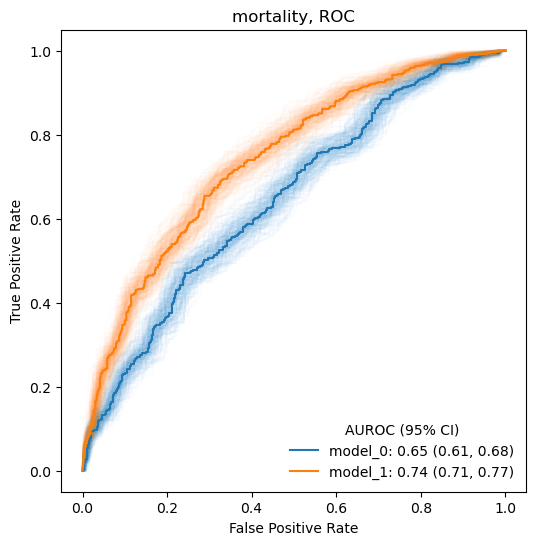

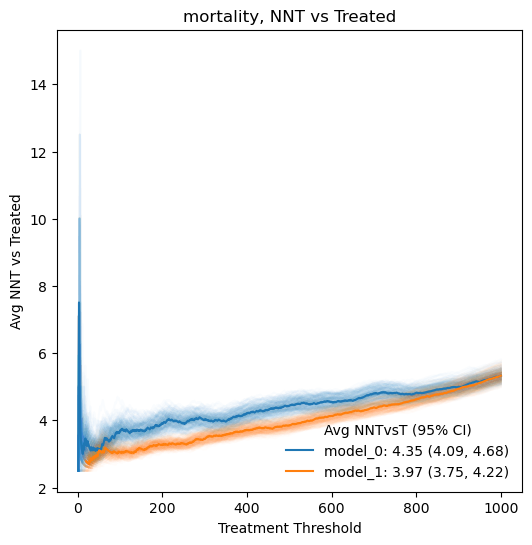

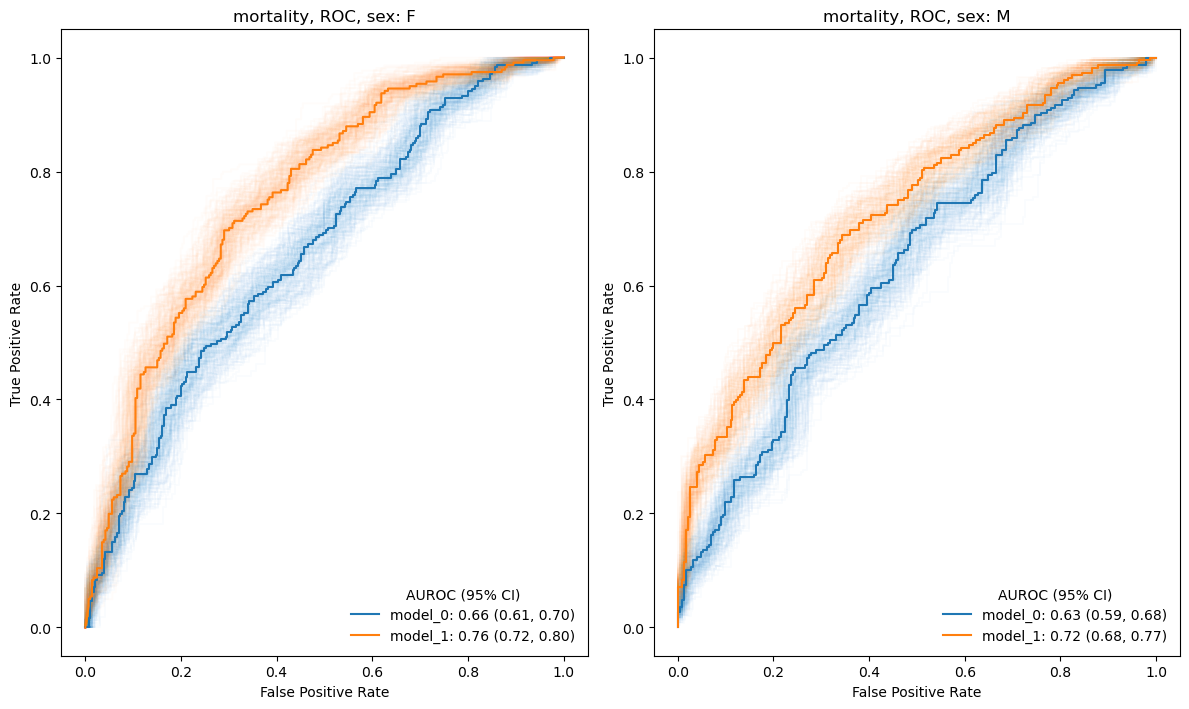

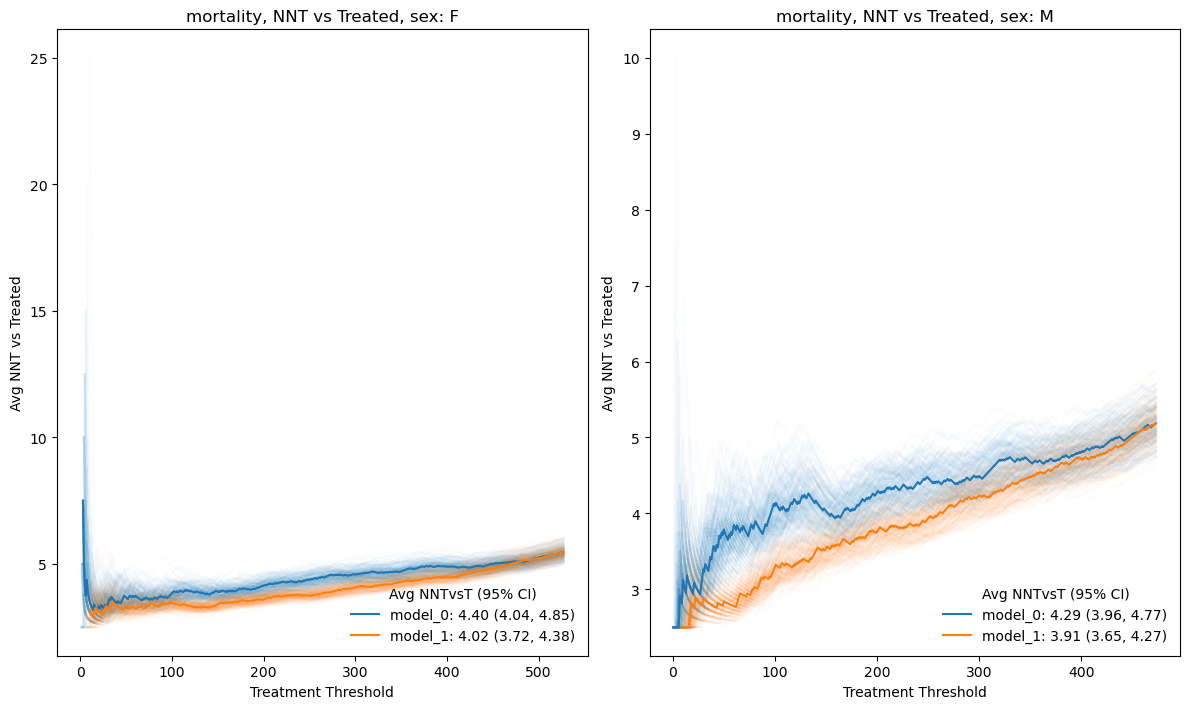

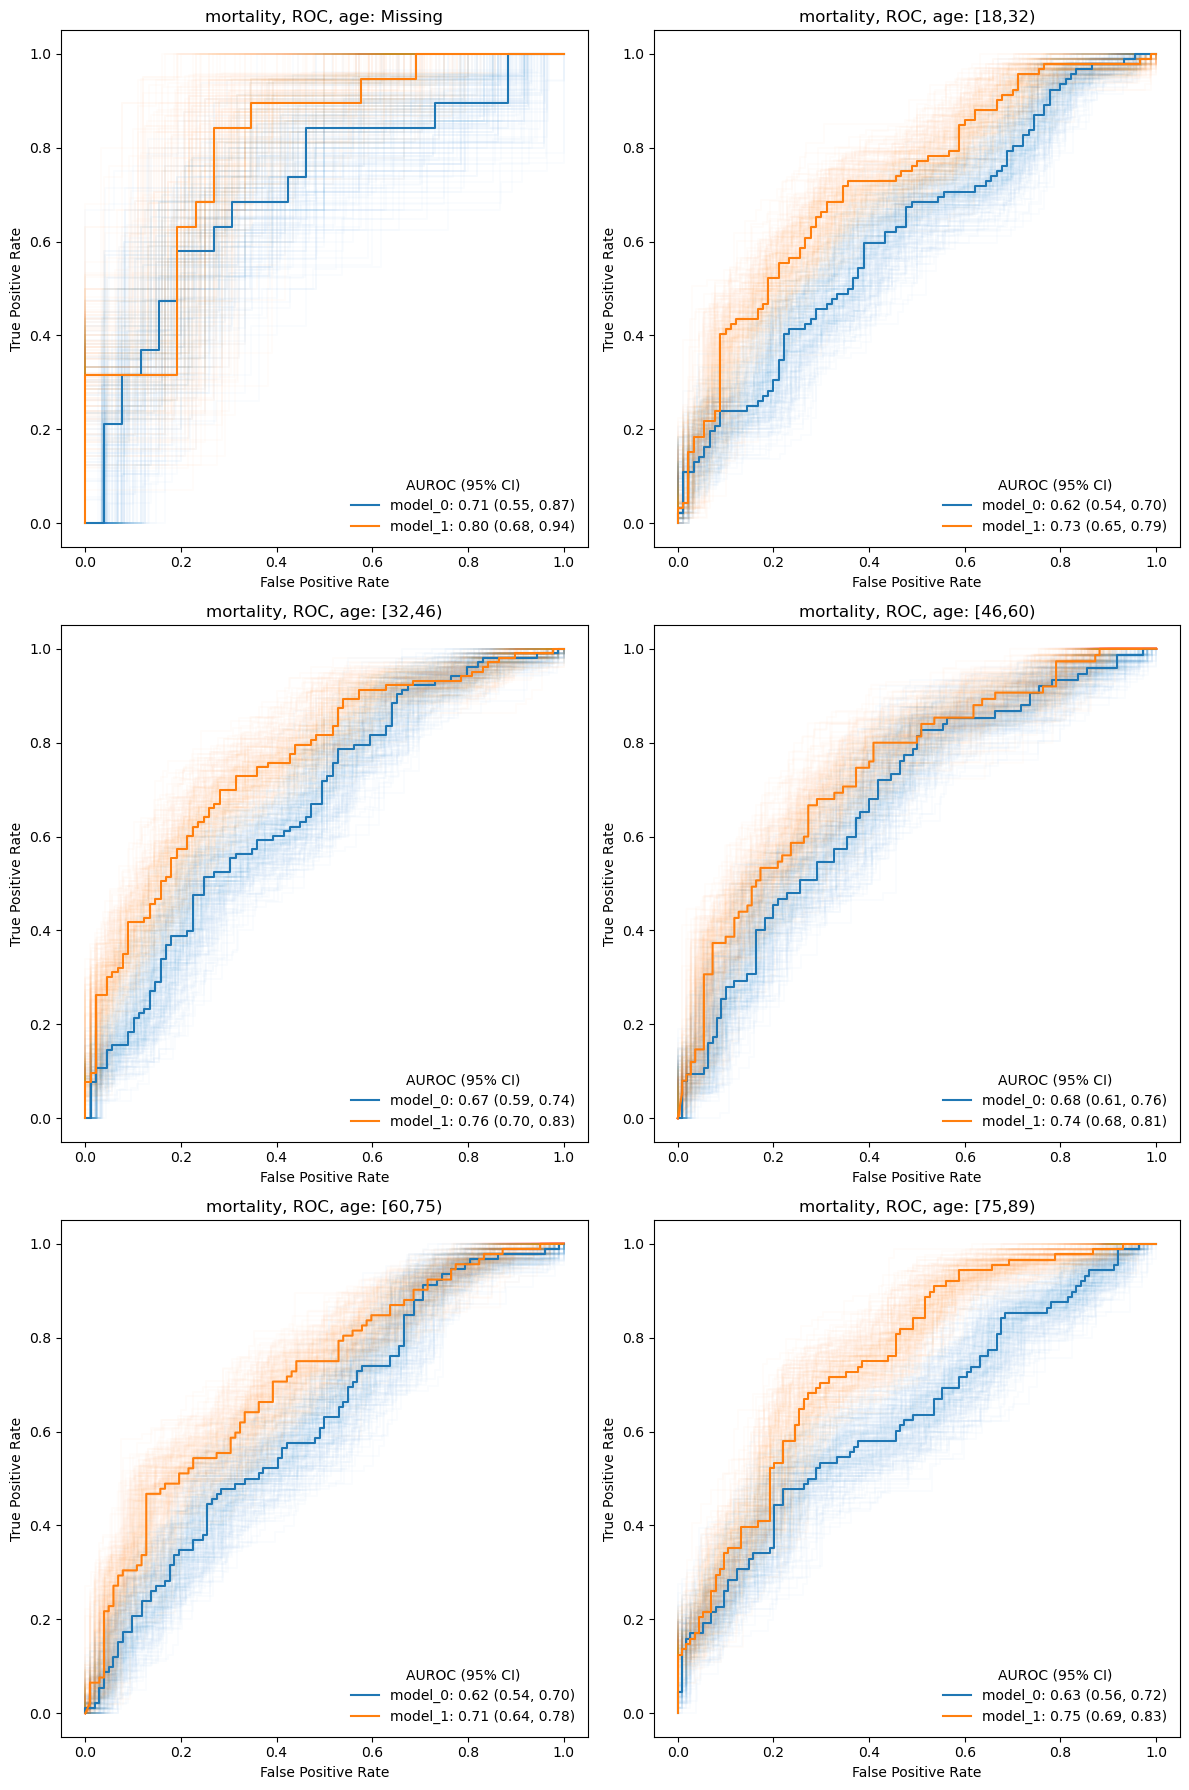

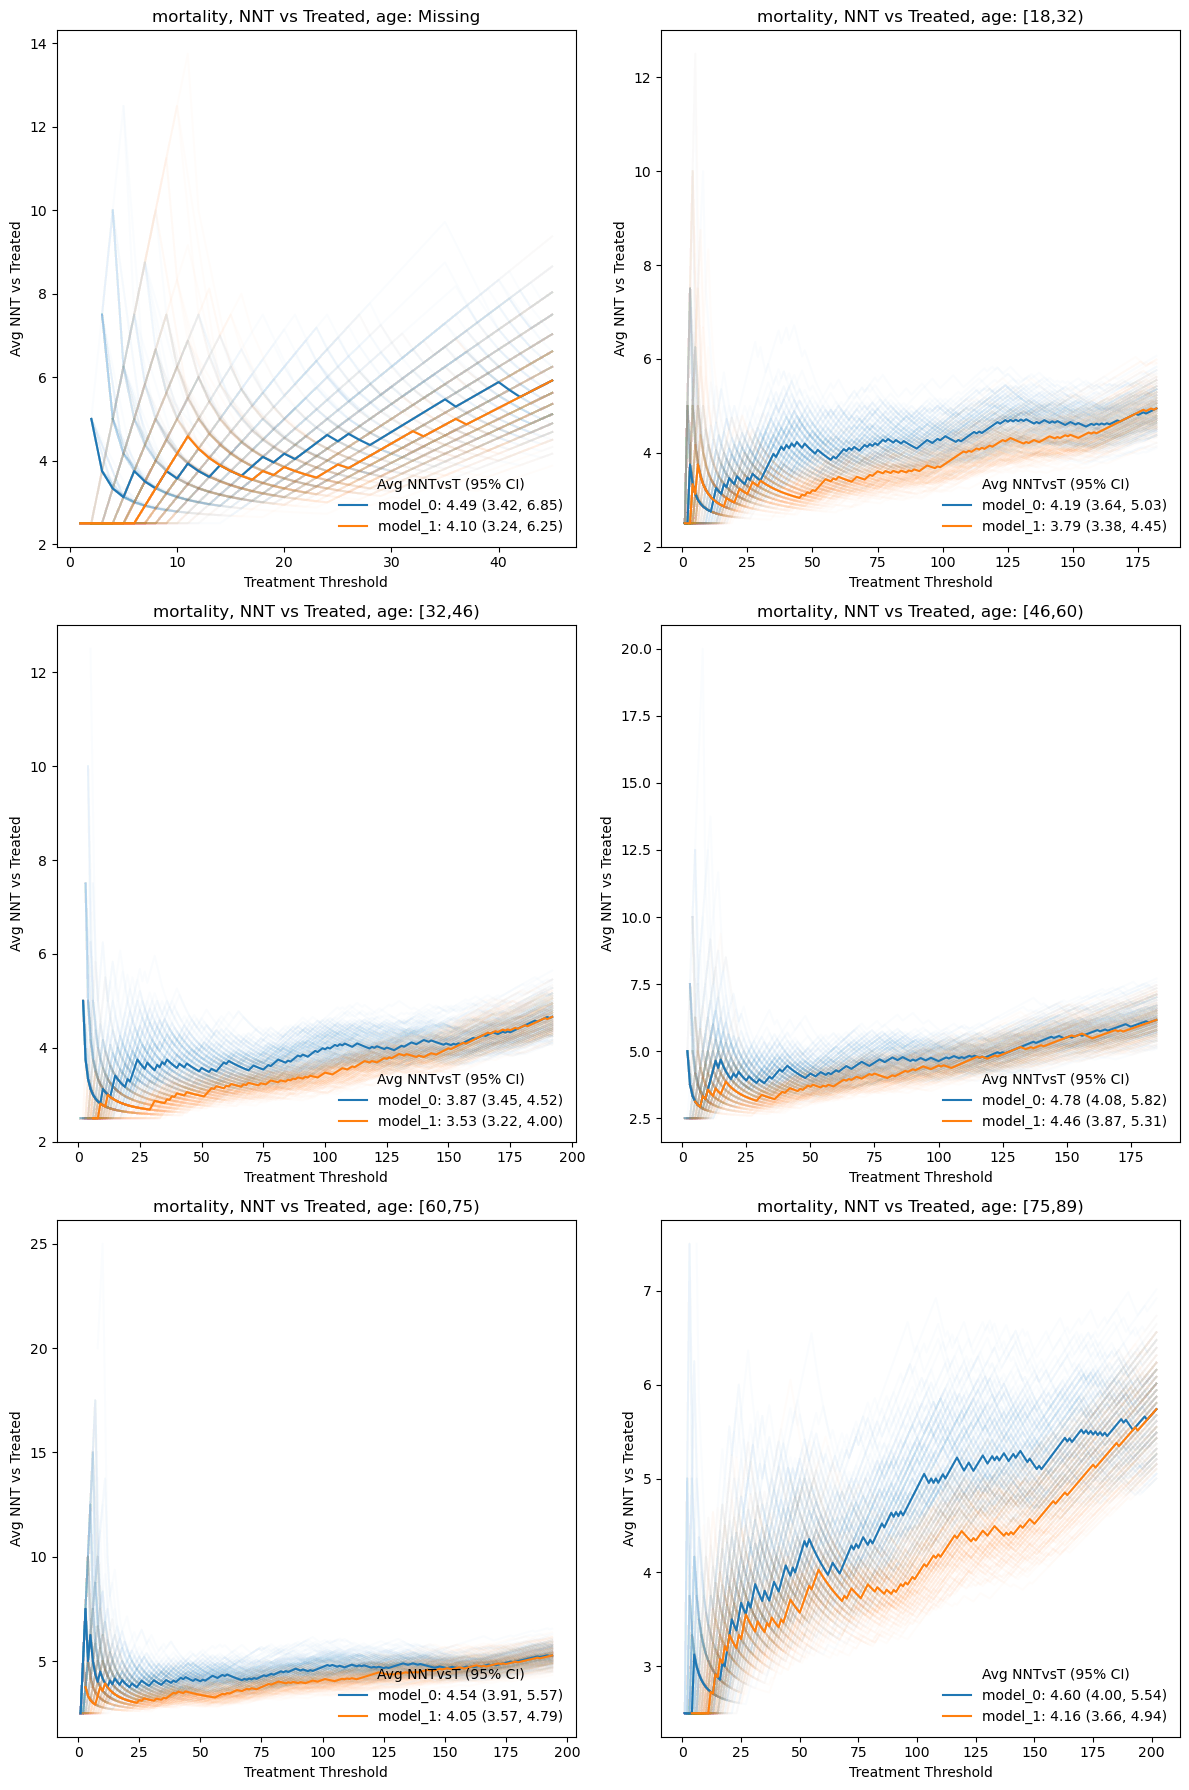

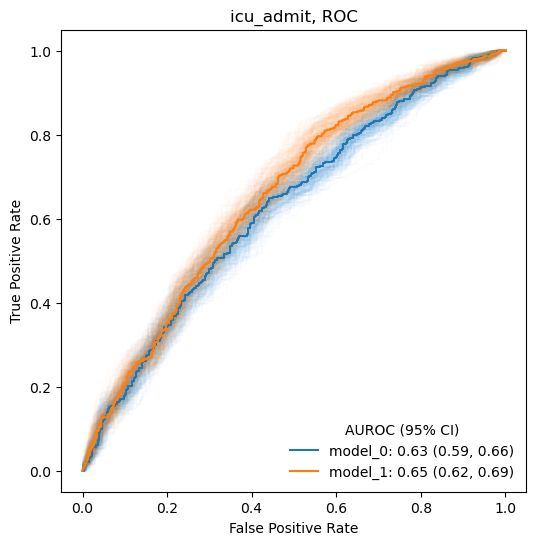

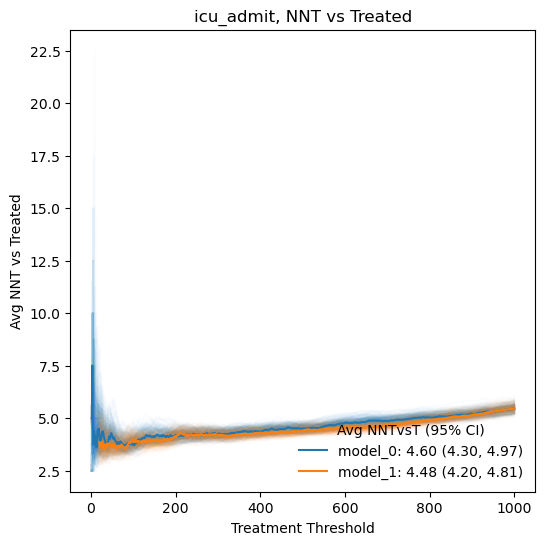

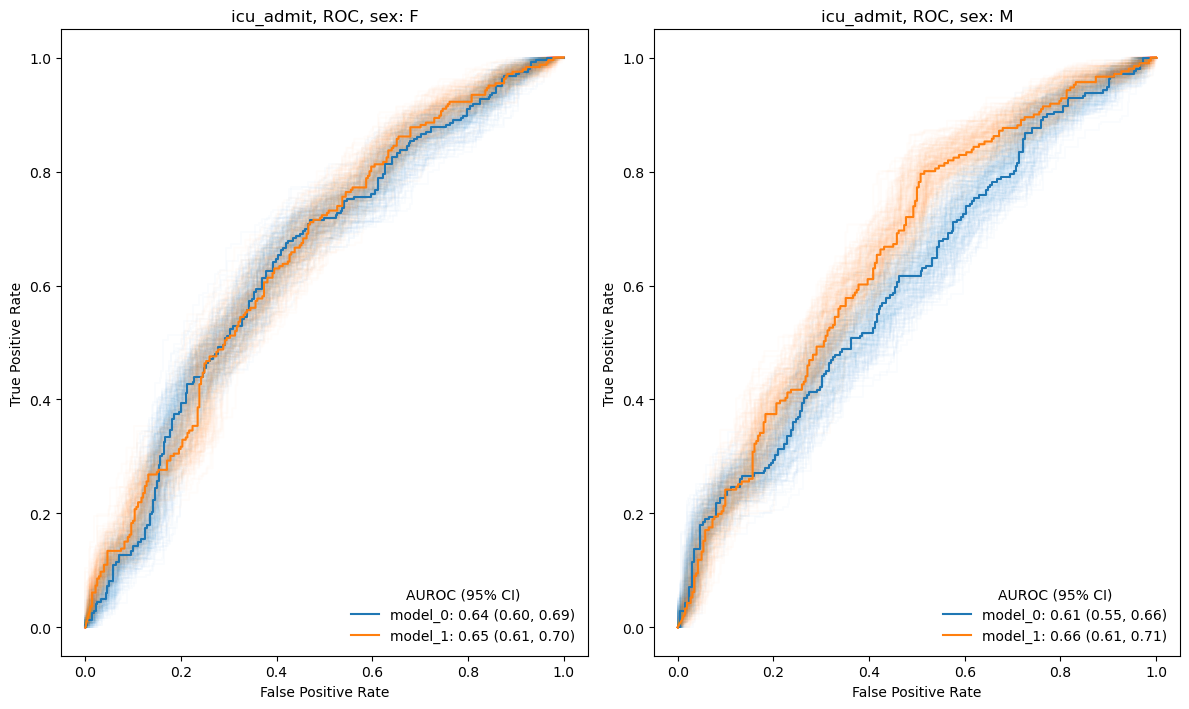

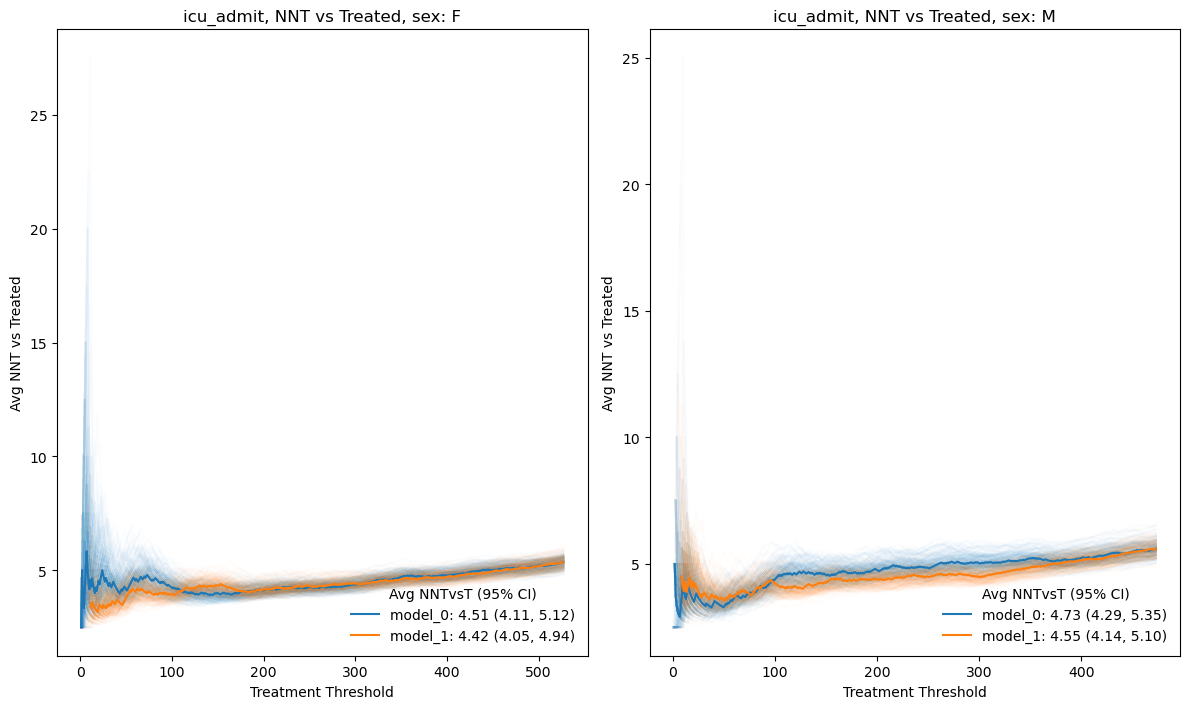

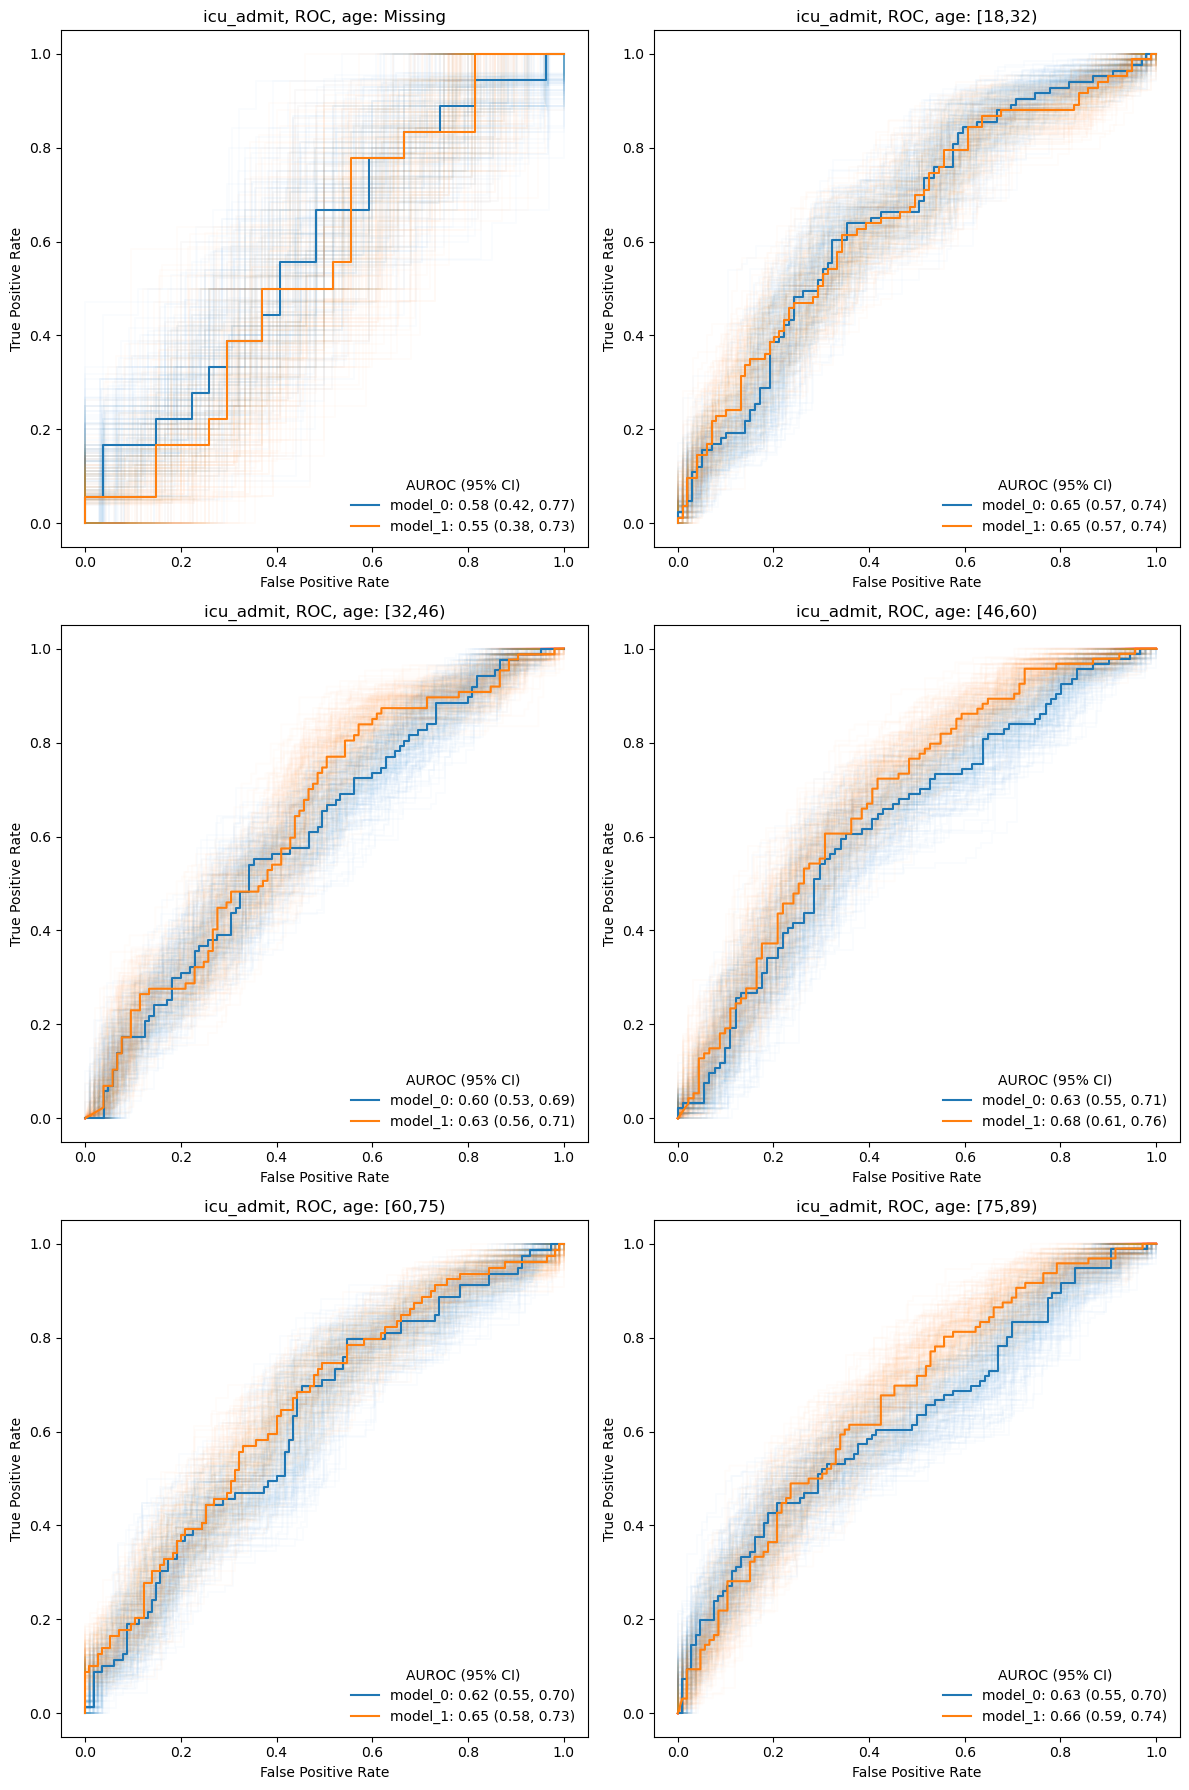

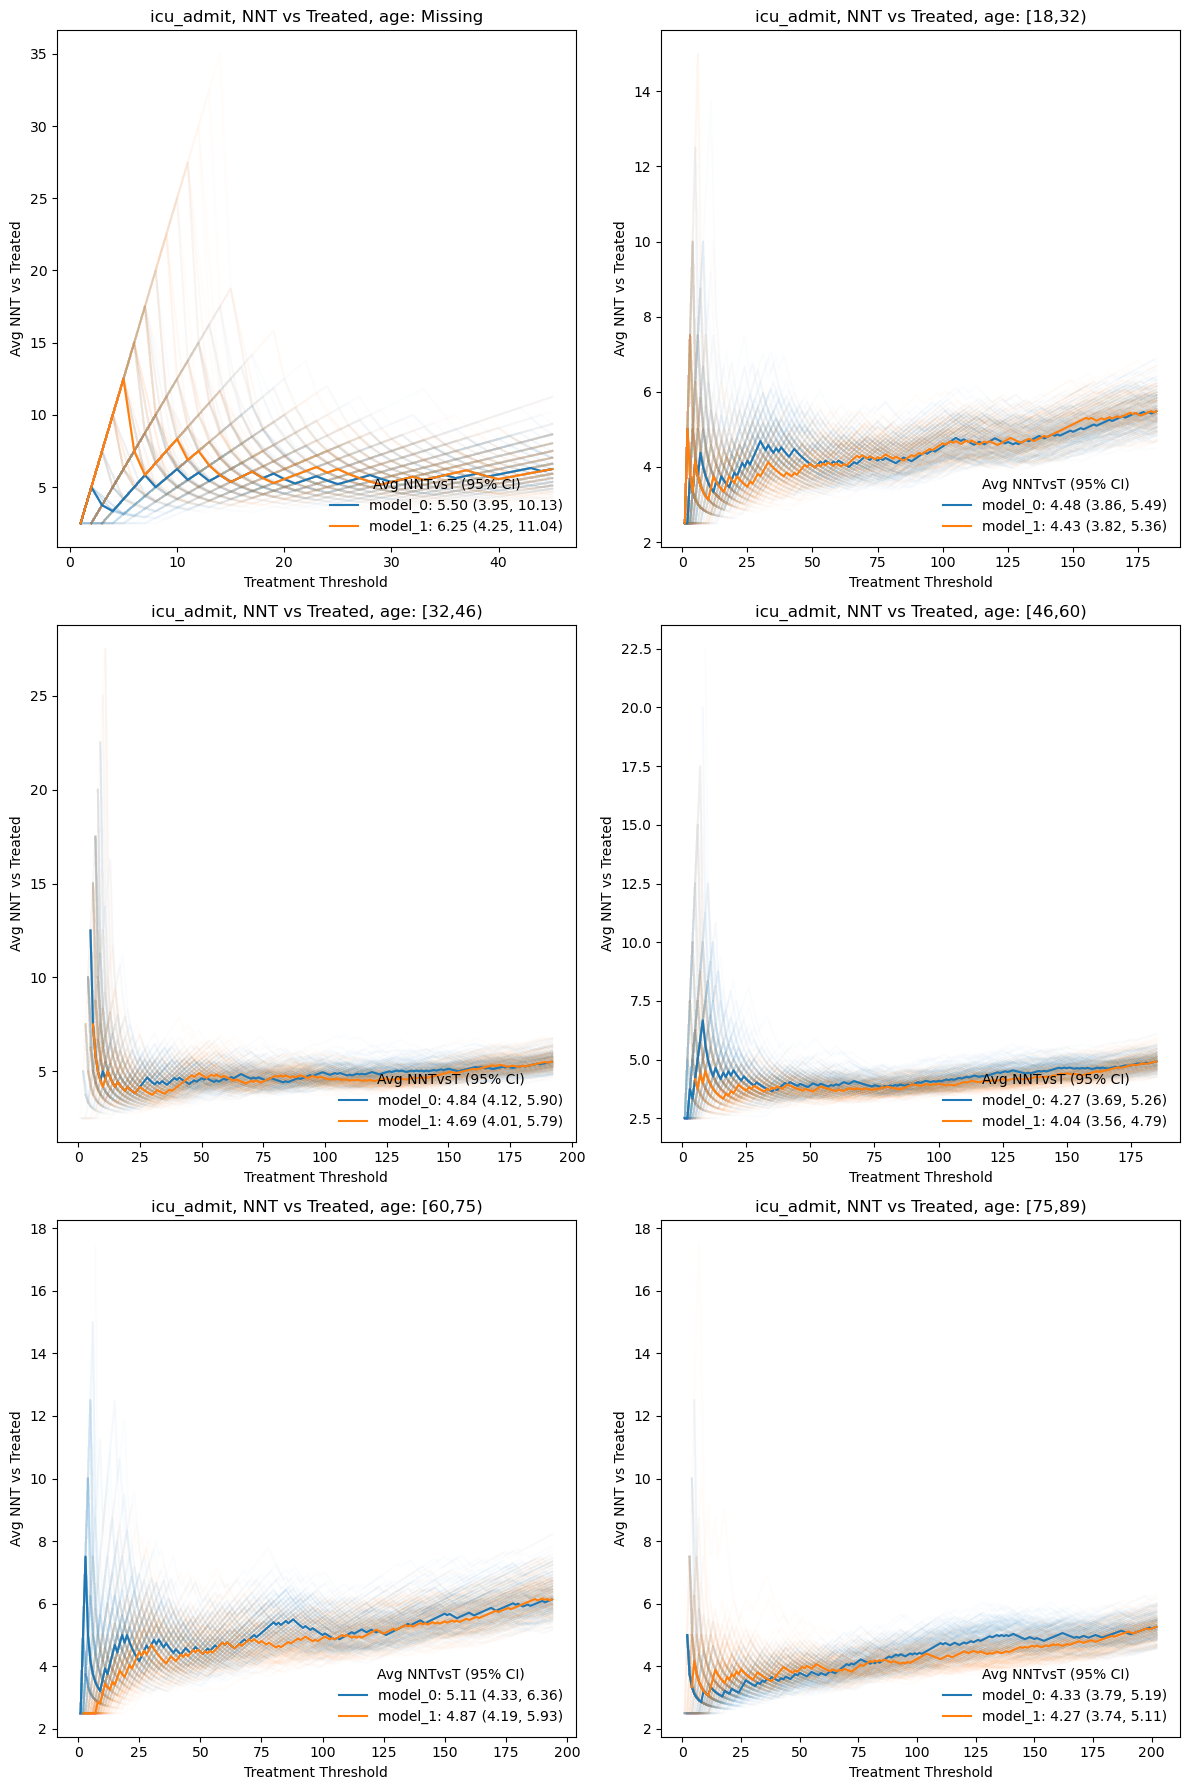

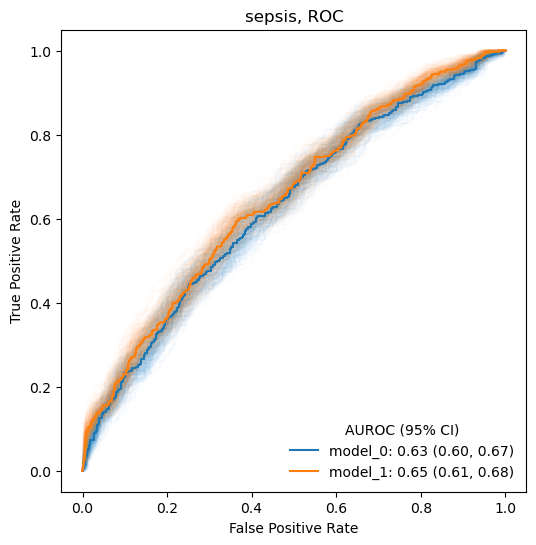

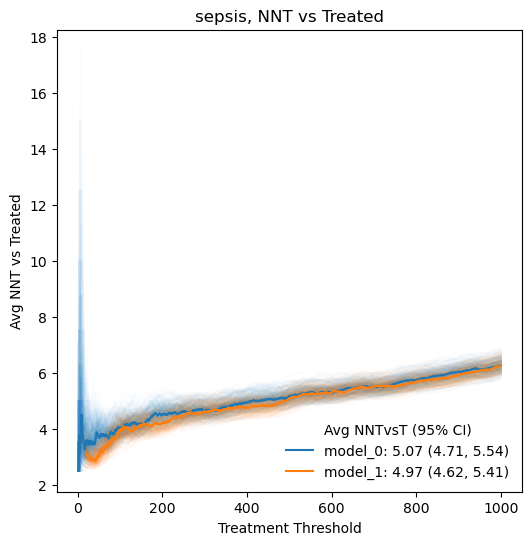

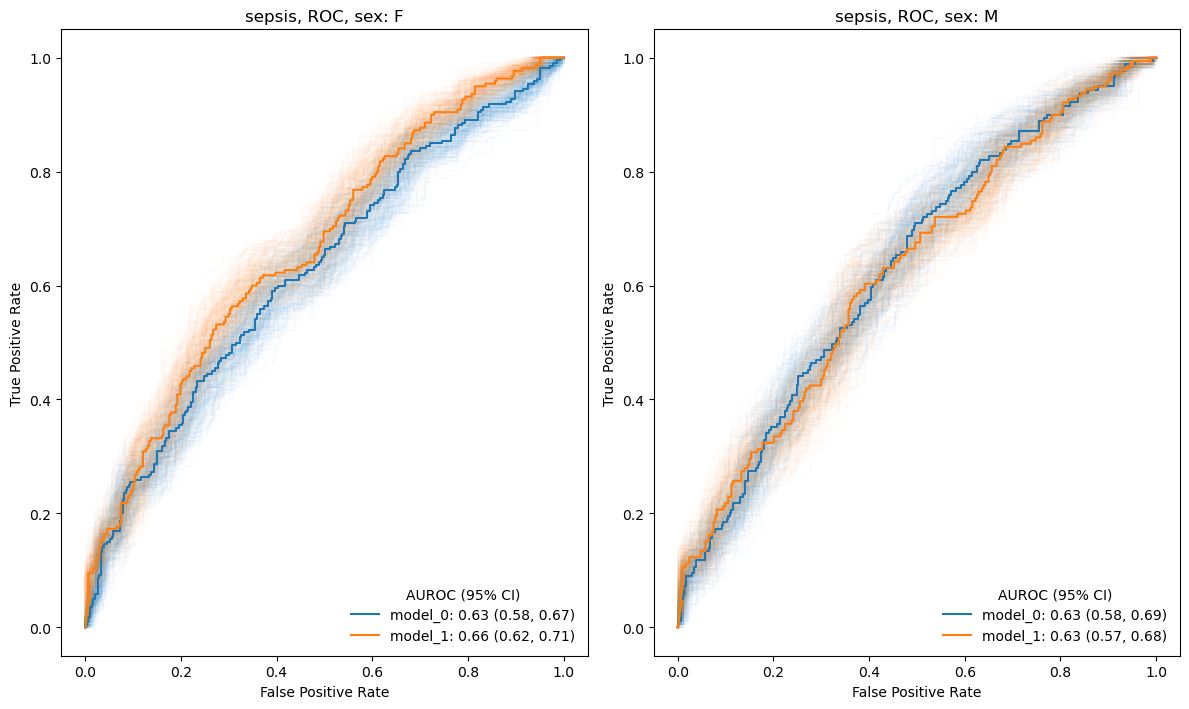

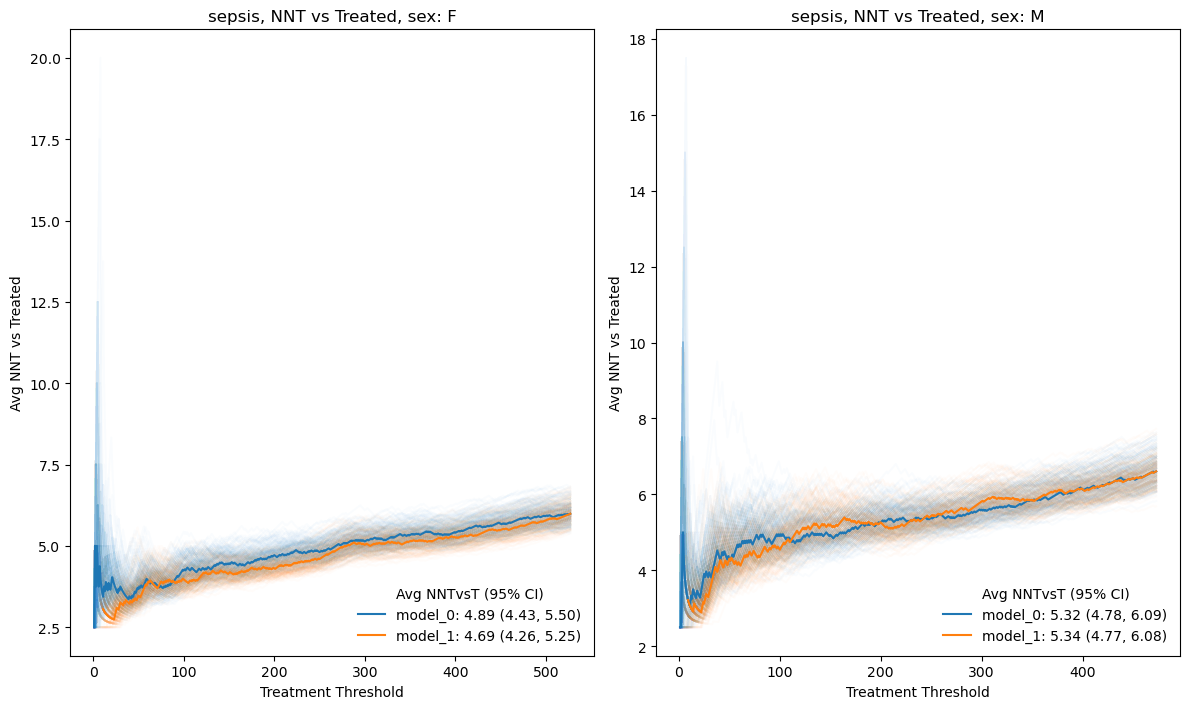

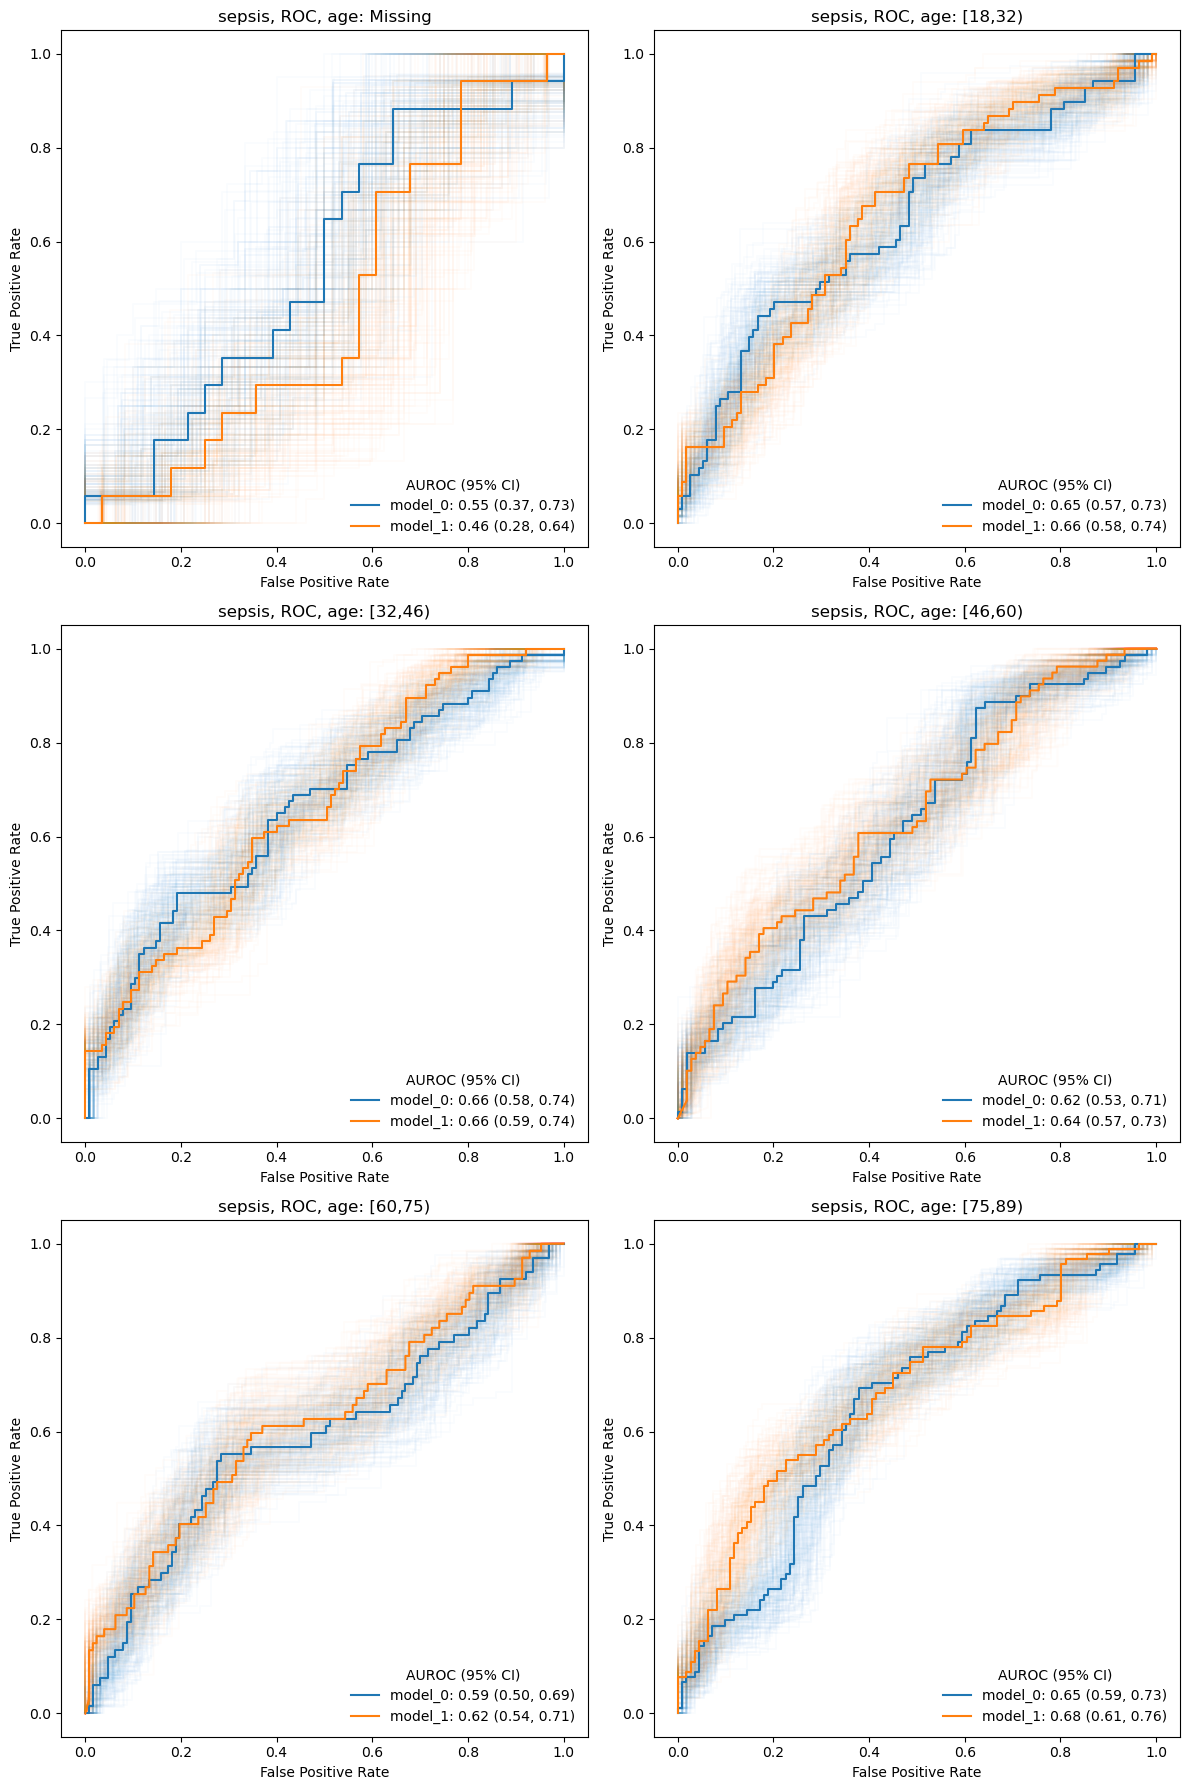

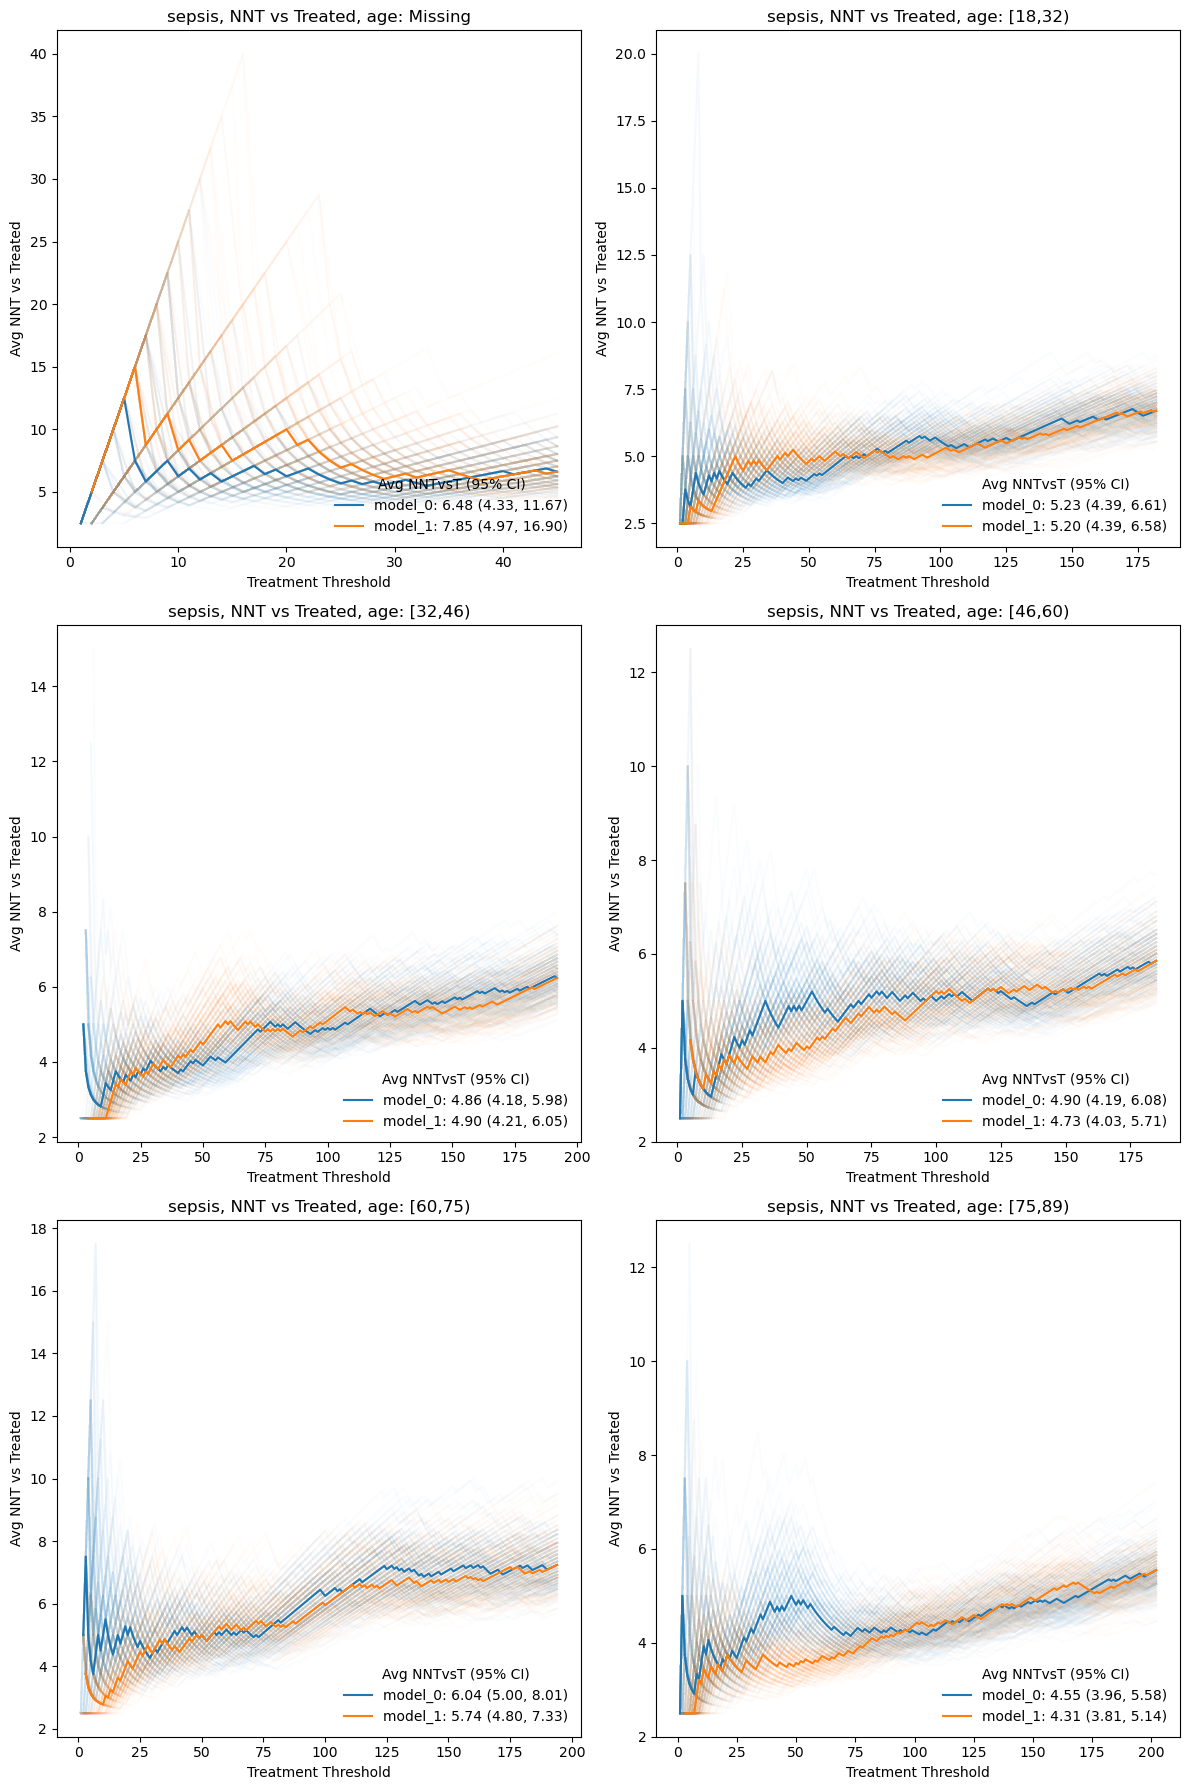

In [7]:
# --- configure which curves to plot and which metric drives the CI/legend ---
curves = {
    "roc_curve": {
        "metric": "roc_auc_score",
        "xlabel": "False Positive Rate",
        "ylabel": "True Positive Rate",
        "title":  "ROC",
        # optional per-curve overrides (else defaults are used)
        "confidence_level": 0.95,
        "method": "basic",          # or "percentile"
        "legend_title": "AUROC"
    },
    "NNTvsT": {
        "metric": "average_NNTvsTreated",
        "xlabel": "Treatment Threshold",
        "ylabel": "Avg NNT vs Treated",
        "title":  "NNT vs Treated",
        "confidence_level": 0.95,
        "method": "percentile",
        "legend_title": "Avg NNTvsT"
    }
}

# --- make figures (overall + subgroup figures for each label) ---
figs = make_curve_figures(
    bootstrapped_results,
    curves,
    y_score_names=["model_0", "model_1"],  # or None for all models present
    include_overall=True,
    include_groups=True,
    label_order=["mortality", "icu_admit"], # optional display order
    group_order=["sex", "age"],             # subgroup order
    show=True,                              # call plt.show() for each figure
    figsize=(6, 6),
    rep_line_alpha=0.02,                    # spaghetti transparency
    line_alpha=1.0,
    max_rep_lines_per_model=200,            # cap for speed/clarity
    legend_title_ci_flag=True,
    save_dir="figs",                        # optional: write PNGs to ./figs
    save_format="png",
    dpi=150
)

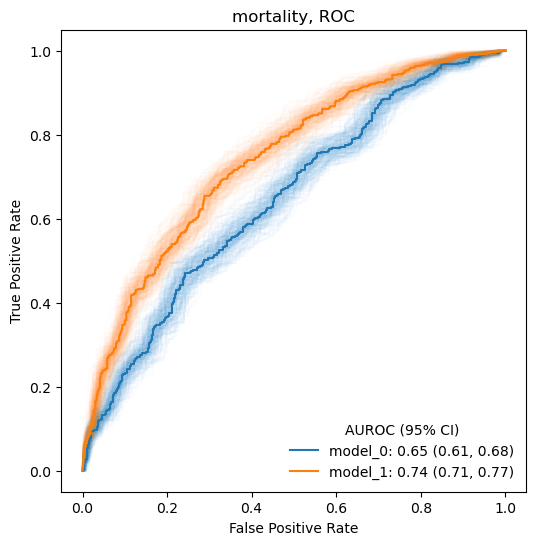

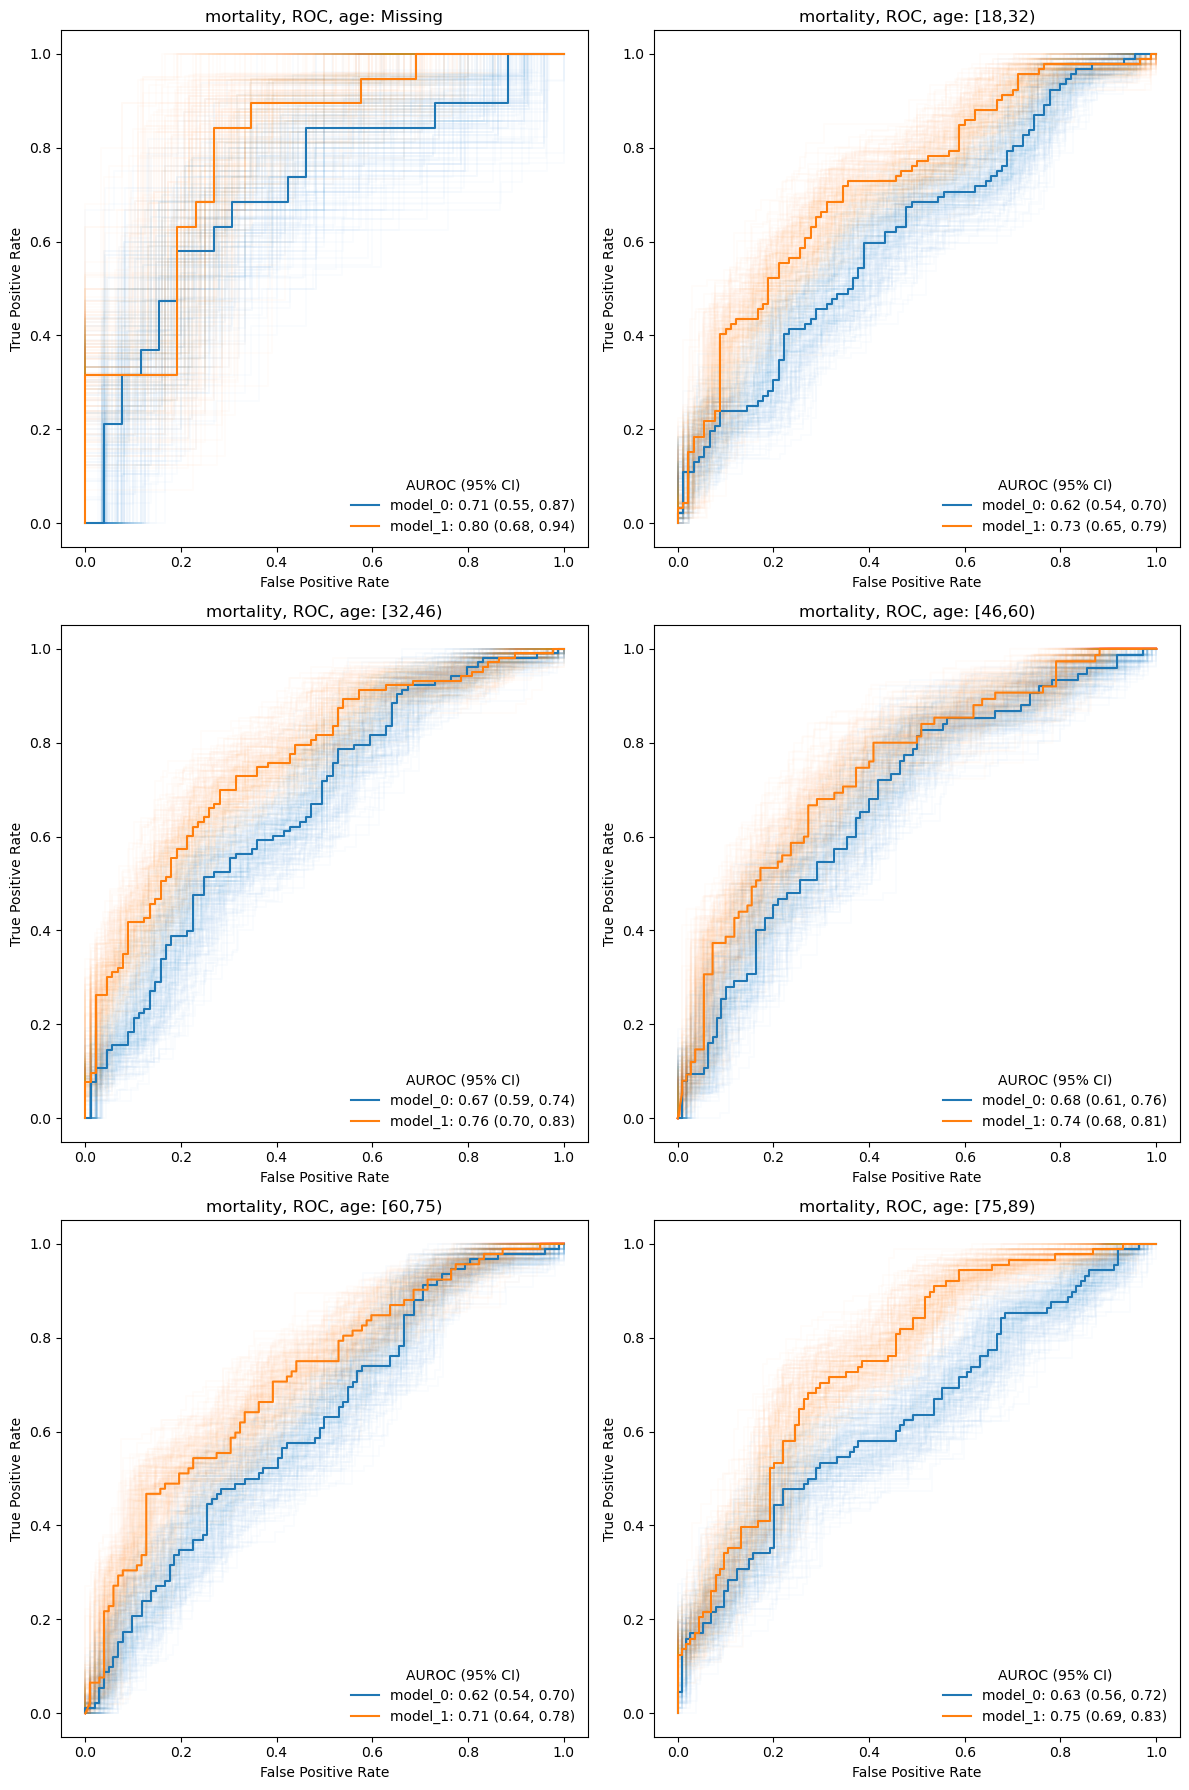

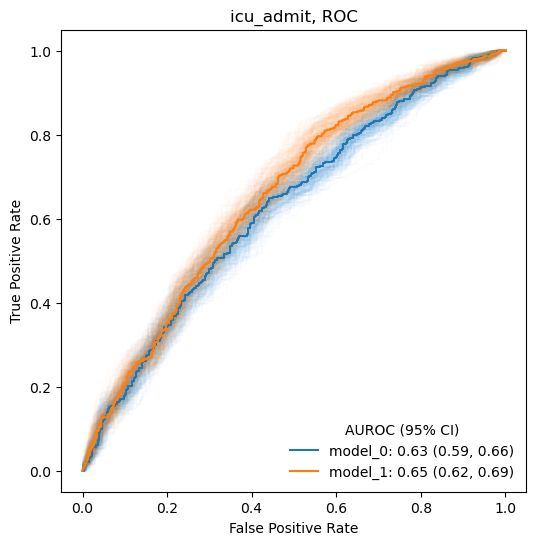

In [8]:
# --- examples: accessing figures from the nested return dict ---

# 1) Overall ROC for label='mortality'
fig_overall_roc_mort = figs["mortality"]["overall"]["roc_curve"]
display(fig_overall_roc_mort)

# 2) Subgroup panel figure (all age levels in one panel) for label='mortality'
fig_panel_age_roc_mort = figs["mortality"]["groups"]["age"]["roc_curve"]
display(fig_panel_age_roc_mort)

#    If you want a specific subplot (Axes) from the panel:
axes = fig_panel_age_roc_mort.get_axes()   # flat list of Axes in row-major order
ax0 = axes[0]                              # e.g., the first age-bin subplot

# 3) Overall ROC for label='icu_admit'
fig_overall_roc_icu = figs["icu_admit"]["overall"]["roc_curve"]
display(fig_overall_roc_icu)

In [9]:
bootstrapped_results.keys()

dict_keys(['mortality', 'icu_admit', 'sepsis', '_metadata'])

In [10]:
bootstrapped_results['mortality'].keys()

dict_keys(['original_metrics', 'original_curves', 'original_compatibility_metrics', 'bootstrap_replication_metrics', 'bootstrap_replication_curves', 'bootstrap_compatibility_metrics', 'original_label_metrics', 'bootstrap_label_metrics', '_metadata', 'groups'])

In [11]:
def dict_tree(obj, *, max_depth=None, max_list=10, show_types=False, prefix=""):
    """
    Pretty print a nested mapping like `tree`.

    Args:
        obj: dict or any nested structure of dicts/lists/tuples/sets.
        max_depth: optional int, stop descending after this depth.
        max_list: max items to show from sequences before eliding.
        show_types: include value types for leaves.
        prefix: internal use for recursion.
    """
    from collections.abc import Mapping, Sequence, Set

    def fmt_leaf(v):
        t = type(v).__name__
        s = repr(v)
        if len(s) > 60:
            s = s[:57] + "..."
        return f"{s} <{t}>" if show_types else s

    def iter_children(x):
        if isinstance(x, Mapping):
            for k in x:
                yield ("dict", k, x[k])
        elif isinstance(x, (Sequence, Set)) and not isinstance(x, (str, bytes, bytearray)):
            x_list = list(x)
            n = len(x_list)
            limit = min(n, max_list)
            for i in range(limit):
                yield ("seq", f"[{i}]", x_list[i])
            if n > limit:
                yield ("ellipsis", f"... {n - limit} more", None)

    def is_branch(x):
        return isinstance(x, Mapping) or (
            isinstance(x, (Sequence, Set)) and not isinstance(x, (str, bytes, bytearray))
        )

    def _walk(node, name="", depth=0, pref=""):
        if name:
            print(pref + name)
        if max_depth is not None and depth >= max_depth:
            if is_branch(node):
                print(pref + "└── (max depth reached)")
            return
        kids = list(iter_children(node)) if is_branch(node) else []
        last_idx = sum(1 for k in kids if k[0] != "ellipsis") - 1

        idx = -1
        for kind, child_name, child_val in kids:
            is_last = (idx + 1) == last_idx if kind != "ellipsis" else True
            branch = "└── " if is_last else "├── "
            next_pref = pref + ("    " if is_last else "│   ")

            if kind == "ellipsis":
                print(pref + branch + child_name)
                continue

            if is_branch(child_val):
                print(pref + branch + str(child_name) + "/")
                _walk(child_val, "", depth + 1, next_pref)
            else:
                print(pref + branch + f"{child_name}: {fmt_leaf(child_val)}")

            if kind != "ellipsis":
                idx += 1

    root_name = "<root>/" if is_branch(obj) else "<root>: " + fmt_leaf(obj)
    print(root_name)
    if is_branch(obj):
        _walk(obj, "", 0, "")


In [12]:
dict_tree(bootstrapped_results, max_list=1)

<root>/
├── mortality/
│   ├── original_metrics/
│   │   ├── roc_auc_score/
│   │   │   ├── model_0: 0.6463003786555519
│   │   │   ├── model_1: 0.739165351611595
│   │   │   └── model_2: 0.6751954513148544
│   │   └── average_NNTvsTreated/
│   │       ├── model_0: np.float64(4.352012235082915)
│   │       ├── model_1: np.float64(3.966649835881784)
│   │       └── model_2: np.float64(4.551220631474778)
│   ├── original_curves/
│   │   ├── roc_curve/
│   │   │   ├── model_0/
│   │   │   │   └── [0]: array([0.        , 0.        , 0.00376648, 0.00376648, 0....
│   │   │   │   └── ... 2 more
│   │   │   ├── model_1/
│   │   │   │   └── [0]: array([0.        , 0.00376648, 0.00376648, 0.00564972, 0....
│   │   │   │   └── ... 2 more
│   │   │   └── model_2/
│   │   │       └── [0]: array([0.        , 0.26553672, 0.26741996, 0.26741996, 0....
│   │   │       └── ... 2 more
│   │   └── NNTvsT/
│   │       ├── model_0/
│   │       │   └── [0]: array([   0.,    1.,    2.,    3.,    4.,    5.,  